# MNIST with PyTorch-GPU and uv

## Imports:

In [1]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
print(torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

2.11.0+cu130
cuda


## Dataset:

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [4]:
torch.manual_seed(42)

train_split_size = int(0.8 * len(train_dataset))

train_dataset, val_dataset = random_split(train_dataset, [train_split_size, len(train_dataset) - train_split_size])

In [5]:
print(f"Total train images: {len(train_dataset)}")
print(f"total validation images: {len(val_dataset)}")
print(f"Total test images: {len(test_dataset)}")

Total train images: 48000
total validation images: 12000
Total test images: 10000


In [6]:
torch.manual_seed(42)

batch_size = 512

n_workers = 8

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=n_workers,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=n_workers,
    pin_memory=True,
    persistent_workers=True
)

## Model Training:

In [7]:
class MNIST_DNN(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.dense = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )

        self.classifier = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.dense(x)
        logits = self.classifier(x)

        return logits

In [8]:
torch.manual_seed(42)

model = MNIST_DNN().to(device)

In [ ]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [10]:
epochs = 20

train_loss = []
val_loss   = []
train_acc  = []
val_acc    = []

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct_train = 0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        y_pred = model(x)
        loss = loss_fn(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.detach() * x.size(0)
        preds = torch.argmax(y_pred, dim = 1)
        correct_train += (preds == y).sum()

    epoch_train_loss = running_loss.item() / len(train_loader.dataset)
    epoch_train_acc = (correct_train.item() / len(train_loader.dataset)) * 100

    model.eval()

    running_val_loss = 0.0
    correct_val = 0

    with torch.inference_mode():
        for x, y in val_loader:

            x = x.to(device)
            y = y.to(device)

            val_pred = model(x)
            current_val_loss = loss_fn(val_pred, y)

            running_val_loss += current_val_loss.detach() * x.size(0)
            val_preds = torch.argmax(val_pred, dim = 1)
            correct_val += (val_preds == y).sum()

    epoch_val_loss = running_val_loss.item() / len(val_loader.dataset)
    epoch_val_acc = (correct_val.item() / len(val_loader.dataset)) * 100

    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.4f} (Acc: {epoch_train_acc:.2f}%) | "
          f"Val Loss: {epoch_val_loss:.4f} (Acc: {epoch_val_acc:.2f}%)")
    
    train_loss.append(epoch_train_loss)
    train_acc.append(epoch_train_acc)
    val_loss.append(epoch_val_loss)
    val_acc.append(epoch_val_acc)

Epoch 01/20 | Train Loss: 0.5401 (Acc: 85.59%) | Val Loss: 0.2695 (Acc: 92.28%)
Epoch 02/20 | Train Loss: 0.1969 (Acc: 94.26%) | Val Loss: 0.1788 (Acc: 94.74%)
Epoch 03/20 | Train Loss: 0.1355 (Acc: 96.01%) | Val Loss: 0.1425 (Acc: 95.82%)
Epoch 04/20 | Train Loss: 0.0999 (Acc: 97.12%) | Val Loss: 0.1232 (Acc: 96.32%)
Epoch 05/20 | Train Loss: 0.0769 (Acc: 97.71%) | Val Loss: 0.1051 (Acc: 96.74%)
Epoch 06/20 | Train Loss: 0.0595 (Acc: 98.22%) | Val Loss: 0.0948 (Acc: 97.18%)
Epoch 07/20 | Train Loss: 0.0474 (Acc: 98.61%) | Val Loss: 0.0987 (Acc: 96.97%)
Epoch 08/20 | Train Loss: 0.0365 (Acc: 98.94%) | Val Loss: 0.0861 (Acc: 97.36%)
Epoch 09/20 | Train Loss: 0.0283 (Acc: 99.25%) | Val Loss: 0.0867 (Acc: 97.34%)
Epoch 10/20 | Train Loss: 0.0227 (Acc: 99.40%) | Val Loss: 0.0803 (Acc: 97.58%)
Epoch 11/20 | Train Loss: 0.0169 (Acc: 99.61%) | Val Loss: 0.0837 (Acc: 97.53%)
Epoch 12/20 | Train Loss: 0.0153 (Acc: 99.62%) | Val Loss: 0.0859 (Acc: 97.37%)
Epoch 13/20 | Train Loss: 0.0107 (Acc: 9

## Model Testing:

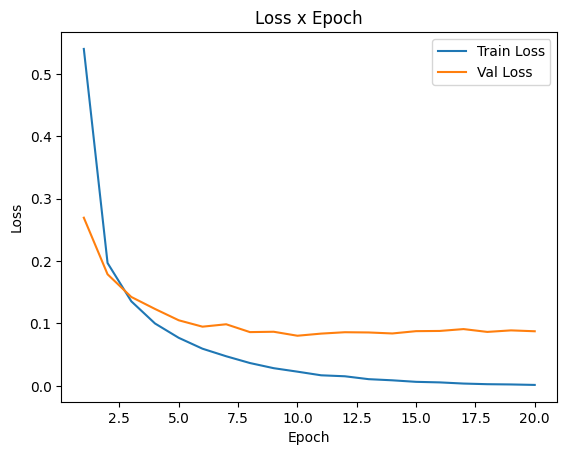

In [11]:
epochs_range = range(1, epochs + 1)

fig, ax = plt.subplots()
ax.plot(epochs_range, train_loss, label="Train Loss")
ax.plot(epochs_range, val_loss,   label="Val Loss")
ax.set_title("Loss x Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

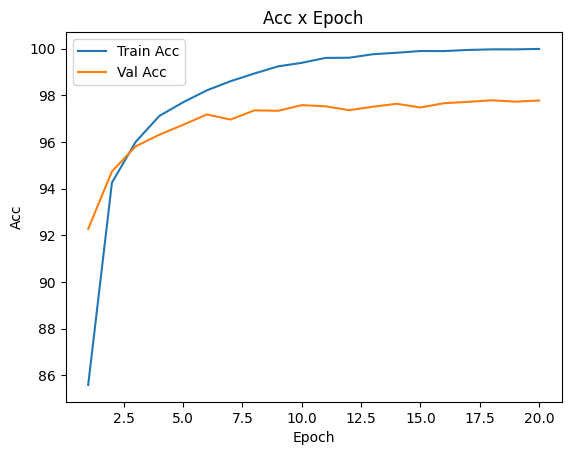

In [12]:
epochs_range = range(1, epochs + 1)

fig, ax = plt.subplots()
ax.plot(epochs_range, train_acc, label="Train Acc")
ax.plot(epochs_range, val_acc,   label="Val Acc")
ax.set_title("Acc x Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Acc")
ax.legend()
plt.show()

In [13]:
count = 0

all_preds = []
all_labels = []

for i in range(len(test_dataset)):
    x_test = test_dataset[i][0].to(device)
    y_pred = torch.argmax(nn.functional.softmax(model(x_test), dim = -1))
    y_test = test_dataset[i][1]

    all_preds.append(y_pred.item())
    all_labels.append(y_test)

    if y_pred == y_test:
        count += 1

print(f"Test accuracy: {100 * count/len(test_dataset):.2f} %")

Test accuracy: 98.12 %


In [14]:
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



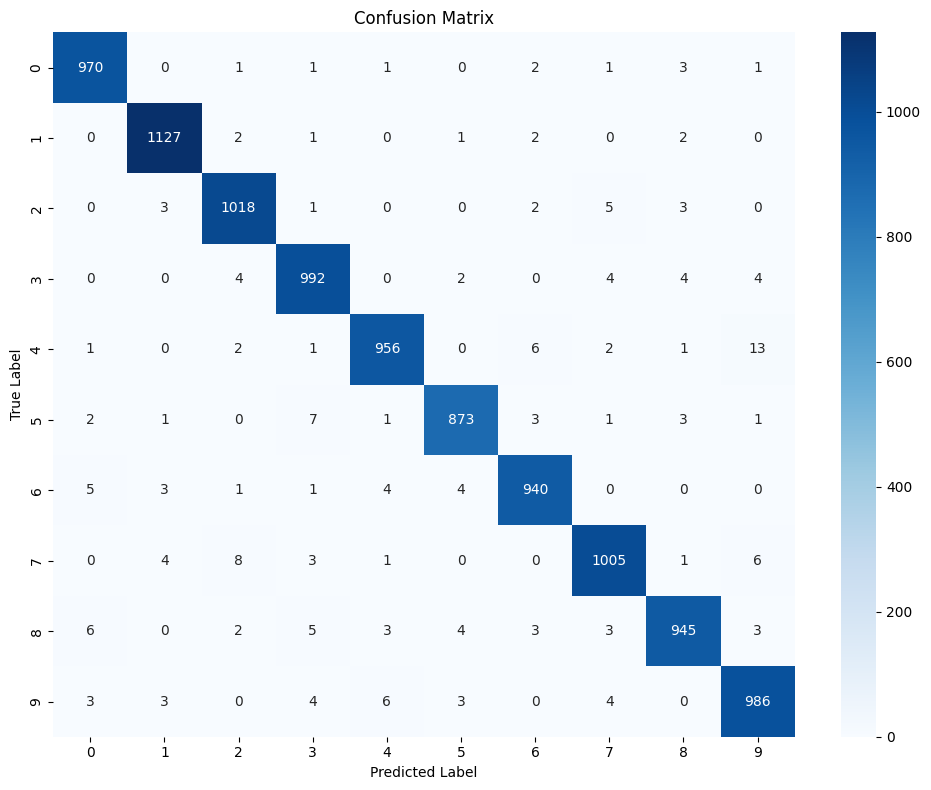

In [15]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=range(10), yticklabels=range(10))
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()